## 1. Importação das bibliotecas

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 2. Carregar dataset

In [4]:
df = pd.read_csv("data/Obesity.csv")

print(df.shape)
df.head()

(2111, 17)


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 3. Análise inicial

In [6]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0
dtype: int64

## 4. Definição da variável target

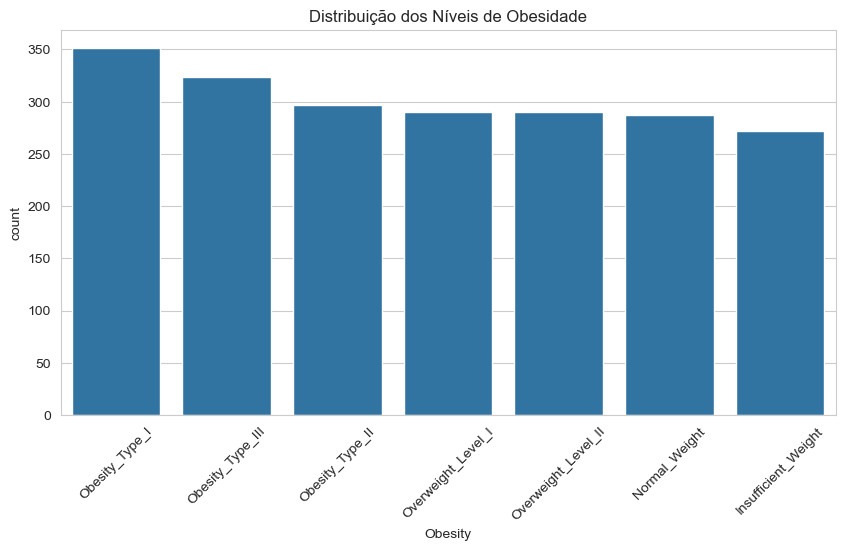

In [8]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Obesity',
    order=df['Obesity'].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Distribuição dos Níveis de Obesidade")
plt.show()

## 5. Distribuição por Sexo

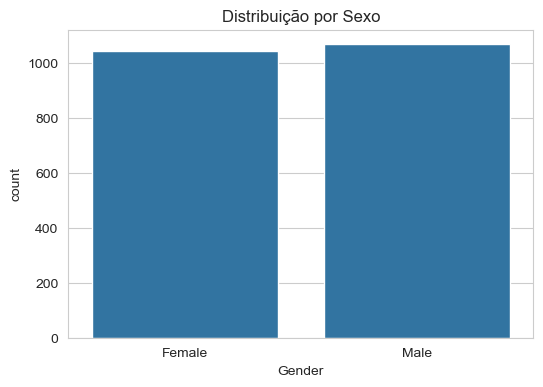

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Gender'
)

plt.title("Distribuição por Sexo")
plt.show()

## 6. Criando IMC para Análise

In [12]:
df['BMI'] = df['Weight'] / (df['Height']**2)

## 7. IMC por Nível de Obesidade

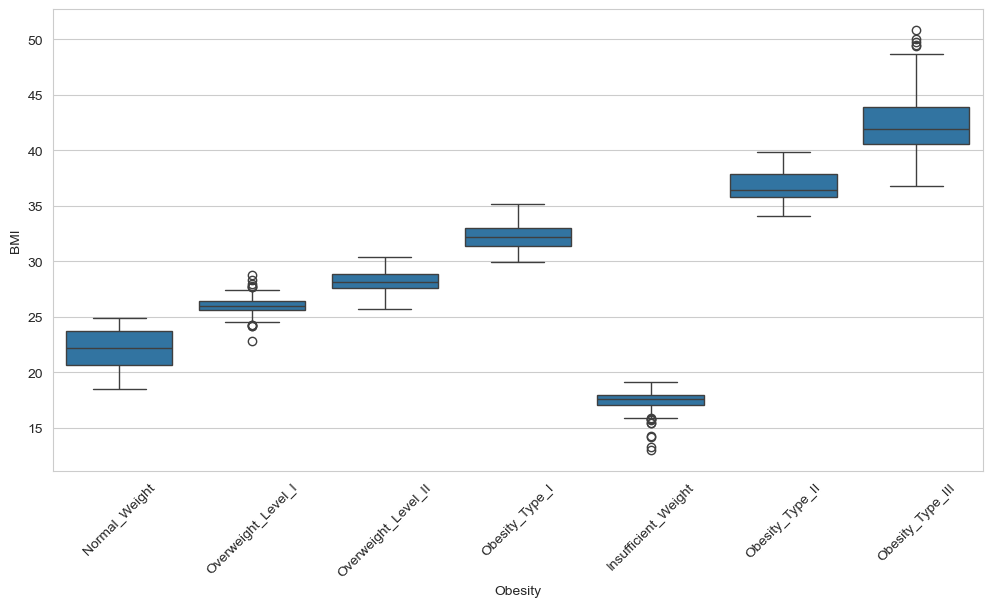

In [14]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Obesity',
    y='BMI'
)

plt.xticks(rotation=45)
plt.show()

## 8. Correlação

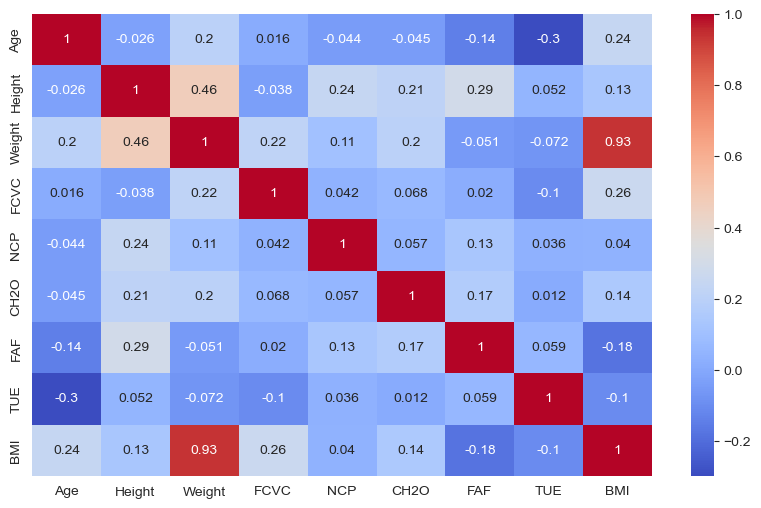

In [16]:
numericas = [
    'Age',
    'Height',
    'Weight',
    'FCVC',
    'NCP',
    'CH2O',
    'FAF',
    'TUE',
    'BMI'
]

plt.figure(figsize=(10,6))

sns.heatmap(
    df[numericas].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

## 9. Hábitos Alimentares

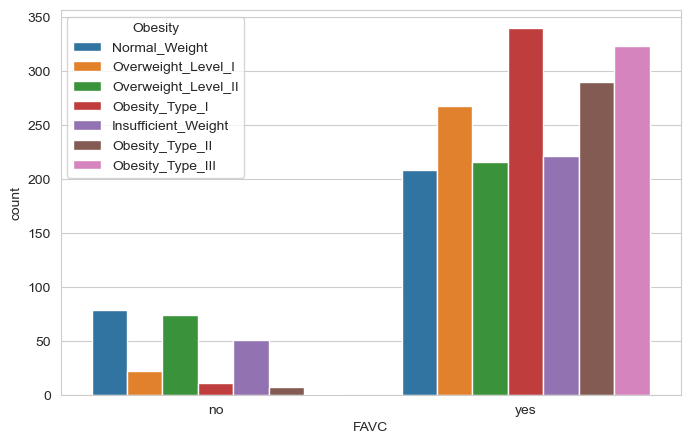

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='FAVC',
    hue='Obesity'
)

plt.show()

## 10. Exercício Físico

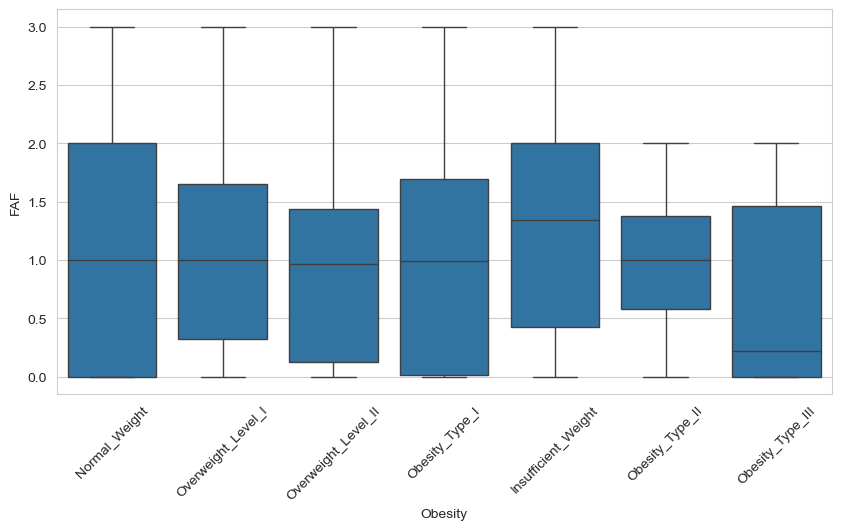

In [20]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='Obesity',
    y='FAF'
)

plt.xticks(rotation=45)
plt.show()

## 11. Principais Insights
- Peso, altura e IMC por obvio apresentam forte associação com obesidade, portanto serao descartados.
- Pacientes sedentários apresentam maior incidência.
- Histórico familiar parece influenciar significativamente.